<a href="https://colab.research.google.com/github/matheus-cmc/atividades_IA_industrial/blob/main/Atividade02_UC04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Você deve criar um Analisador Automático de Fotos

**Contexto:** <br>
Você foi contratado para desenvolver uma ferramenta inteligente de "Análise de Fotos" para uma empresa. O objetivo é que a ferramenta receba uma foto e gere automaticamente um relatório visual sobre cada pessoa na imagem: sua emoção predominante, idade estimada, gênero e etnia.

<br>

**Objetivos de Aprendizagem:**

- Utilizar uma biblioteca de alto nível (deepface) para realizar análise facial complexa com poucas linhas de código.

- Aplicar a função de detecção e análise para extrair múltiplos atributos de um rosto.

- Integrar os resultados da análise com as funções de desenho do OpenCV para criar uma visualização de dados rica e informativa.

- Compreender como frameworks modernos de Deep Learning podem simplificar tarefas avançadas de Visão Computacional.

<br>

**O que é o DeepFace:**

O DeepFace é uma biblioteca de Python de código aberto voltada para reconhecimento e análise facial, que funciona como uma camada de alto nível sobre diferentes modelos de redes neurais convolucionais já treinados. Com ela, é possível de forma simples e prática realizar tarefas como verificação de identidade (comparar se duas fotos são da mesma pessoa) e análise de atributos faciais, incluindo estimativa de idade, gênero, emoções e raça/etnia, sem necessidade de treinar modelos do zero. Essa facilidade de uso faz com que o DeepFace seja muito utilizado em aplicações, tornando-se uma ferramenta poderosa para explorar o potencial da visão computacional aplicada a rostos.

<br>

---

ORIENTAÇÕES:

---



In [ ]:
!pip install -q deepface opencv-python matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.3/128.3 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 57.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 52.8 MB/s eta 0:00:00


In [ ]:
#Importação das bibliotecas
from deepface import DeepFace
import cv2
import matplotlib.pyplot as plt

25-11-17 22:26:55 - Directory /root/.deepface has been created
25-11-17 22:26:55 - Directory /root/.deepface/weights has been created


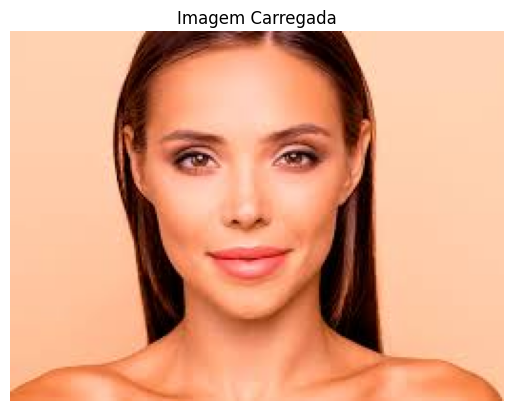

In [ ]:
#1. Importar uma foto para o google colab
caminho_imagem = "/content/foto.jpeg"

#2. Carregar a imagem
imagem_bgr = cv2.imread(caminho_imagem)

#3. Converter a imagem para tons (visualizar corretamente a imagem)
imagem_rgb = cv2.cvtColor(imagem_bgr, cv2.COLOR_BGR2RGB)

#4. Visualização da imagem
plt.imshow(imagem_rgb)
plt.title("Imagem Carregada")
plt.axis('off')
plt.show()

In [ ]:
resultado = DeepFace.analyze(
    img_path=imagem_rgb,              # Caminho ou imagem carregada
    actions=['age','gender','emotion','race'],  # Lista de análises desejadas: idade, gênero, emoção e raça/etnia
    detector_backend='opencv',        # Define o algoritmo usado para detectar o rosto
    enforce_detection=False           # Se False, continua mesmo se o rosto não for detectado claramente
)


# O DeepFace pode trazer dois formatos de resultado:
# - Dicionário: quando só existe UM rosto na imagem
# - Lista de dicionários: quando existem VÁRIOS rostos na imagem
# Neste caso, escolhemos apenas o primeiro rosto detectado

if isinstance(resultado, list) and len(resultado) > 0:
    resultado = resultado[0]  # pega apenas o primeiro rosto da lista

Action: age:   0%|          | 0/4 [00:00<?, ?it/s]    

25-11-17 22:47:44 - 🔗 age_model_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/age_model_weights.h5 to /root/.deepface/weights/age_model_weights.h5...


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/age_model_weights.h5
To: /root/.deepface/weights/age_model_weights.h5

  0%|          | 0.00/539M [00:00<?, ?B/s]
  2%|▏         | 8.91M/539M [00:00<00:06, 86.7MB/s]
  5%|▍         | 26.2M/539M [00:00<00:03, 136MB/s] 
  9%|▉         | 49.8M/539M [00:00<00:02, 181MB/s]
 13%|█▎        | 71.8M/539M [00:00<00:02, 195MB/s]
 17%|█▋        | 91.8M/539M [00:00<00:02, 182MB/s]
 20%|██        | 110M/539M [00:00<00:02, 154MB/s] 
 23%|██▎       | 126M/539M [00:00<00:03, 126MB/s]
 26%|██▌       | 141M/539M [00:01<00:04, 91.5MB/s]
 28%|██▊       | 153M/539M [00:01<00:03, 97.0MB/s]
 32%|███▏      | 170M/539M [00:01<00:03, 114MB/s] 
 35%|███▍      | 187M/539M [00:01<00:02, 126MB/s]
 38%|███▊      | 204M/539M [00:01<00:02, 139MB/s]
 41%|████      | 220M/539M [00:01<00:02, 134MB/s]
 44%|████▍     | 236M/539M [00:01<00:02, 141MB/s]
 47%|████▋     | 252M/539M [00:01<00:02, 143MB/s]
 52%|█████▏    | 279M/539M [00:01<00:

25-11-17 22:48:03 - 🔗 gender_model_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/gender_model_weights.h5 to /root/.deepface/weights/gender_model_weights.h5...


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/gender_model_weights.h5
To: /root/.deepface/weights/gender_model_weights.h5

  0%|          | 0.00/537M [00:00<?, ?B/s]
  2%|▏         | 12.6M/537M [00:00<00:04, 124MB/s]
  5%|▍         | 25.7M/537M [00:00<00:04, 126MB/s]
  7%|▋         | 38.8M/537M [00:00<00:03, 128MB/s]
 10%|▉         | 51.9M/537M [00:00<00:03, 128MB/s]
 12%|█▏        | 65.0M/537M [00:00<00:03, 129MB/s]
 15%|█▍        | 78.1M/537M [00:00<00:03, 119MB/s]
 17%|█▋        | 90.2M/537M [00:00<00:03, 116MB/s]
 19%|█▉        | 103M/537M [00:00<00:03, 119MB/s] 
 21%|██▏       | 115M/537M [00:00<00:03, 112MB/s]
 24%|██▎       | 126M/537M [00:01<00:03, 103MB/s]
 25%|██▌       | 137M/537M [00:01<00:04, 99.1MB/s]
 28%|██▊       | 148M/537M [00:01<00:03, 103MB/s] 
 30%|██▉       | 160M/537M [00:01<00:03, 105MB/s]
 32%|███▏      | 171M/537M [00:01<00:03, 103MB/s]
 34%|███▍      | 182M/537M [00:01<00:03, 104MB/s]
 36%|███▌      | 192M/537M [00:0

25-11-17 22:48:16 - 🔗 facial_expression_model_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/facial_expression_model_weights.h5 to /root/.deepface/weights/facial_expression_model_weights.h5...


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/facial_expression_model_weights.h5
To: /root/.deepface/weights/facial_expression_model_weights.h5

100%|██████████| 5.98M/5.98M [00:00<00:00, 147MB/s]
Action: race:  75%|███████▌  | 3/4 [00:38<00:10, 10.68s/it]   

25-11-17 22:48:19 - 🔗 race_model_single_batch.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/race_model_single_batch.h5 to /root/.deepface/weights/race_model_single_batch.h5...


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/race_model_single_batch.h5
To: /root/.deepface/weights/race_model_single_batch.h5

  0%|          | 0.00/537M [00:00<?, ?B/s]
  5%|▌         | 29.4M/537M [00:00<00:01, 292MB/s]
 13%|█▎        | 67.6M/537M [00:00<00:01, 345MB/s]
 19%|█▉        | 102M/537M [00:00<00:01, 323MB/s] 
 25%|██▌       | 135M/537M [00:00<00:01, 282MB/s]
 31%|███       | 164M/537M [00:00<00:01, 271MB/s]
 36%|███▌      | 192M/537M [00:00<00:01, 271MB/s]
 41%|████      | 220M/537M [00:00<00:01, 243MB/s]
 46%|████▌     | 245M/537M [00:00<00:01, 234MB/s]
 51%|█████▏    | 276M/537M [00:01<00:01, 255MB/s]
 57%|█████▋    | 305M/537M [00:01<00:00, 263MB/s]
 62%|██████▏   | 332M/537M [00:01<00:00, 221MB/s]
 66%|██████▋   | 356M/537M [00:01<00:00, 201MB/s]
 70%|███████   | 377M/537M [00:01<00:00, 196MB/s]
 74%|███████▍  | 398M/537M [00:01<00:00, 187MB/s]
 78%|███████▊  | 417M/537M [00:01<00:00, 161MB/s]
 81%|████████  | 435M/537M [00:01

In [ ]:
genero = resultado.get('dominant_gender', None)

emocao = resultado.get('dominant_emotion', 'desconhecida')

idade = resultado.get('age', 'Desconhecida')

raca = resultado.get("dominant_race", "desconhecida")



print("\n\n === Resultado da análise facial ===")
print(f"Idade (Estimada): {idade}")
print(f"Genero (Estimado): {genero}")
print(f"Emoção Principal: {emocao}")



 === Resultado da análise facial ===
Idade (Estimada): 31
Genero (Estimado): Woman
Emoção Principal: neutral


In [ ]:
# Pega a idade estimada; se não encontrar, mostra "desconhecida"
idade = resultado.get('age', 'desconhecida')

# Pega o gênero dominante (o DeepFace já escolhe o mais provável)
genero = resultado.get('dominant_gender', None)

# Pega a emoção dominante (feliz, triste, bravo, etc.); se não achar, mostra "desconhecida"
emocao_principal = resultado.get('dominant_emotion', 'desconhecida')

# Pega a raça/etnia dominante; se não achar, mostra "desconhecida"
raca_principal = resultado.get('dominant_race', 'desconhecida')


print("\n\n === Resultados da Análise Facial ===")
print(f"Idade (estimada): {idade}")
print(f"Gênero (estimado): {genero}")
print(f"Emoção principal: {emocao_principal}")
print(f"Raça/etnia principal (estimada): {raca_principal}")



 === Resultados da Análise Facial ===
Idade (estimada): 31
Gênero (estimado): Woman
Emoção principal: neutral
Raça/etnia principal (estimada): white


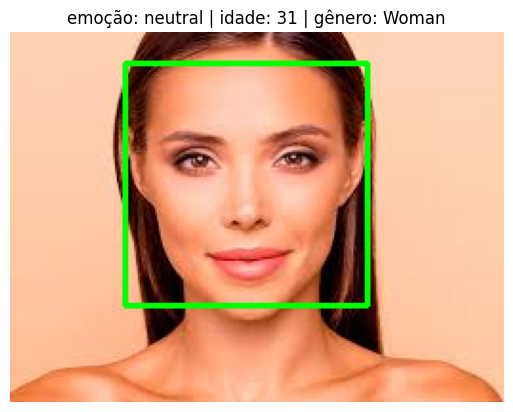

In [ ]:
# Pega a região do rosto detectado (coordenadas da caixa delimitadora)
regiao = resultado.get('region', None)

# Faz uma cópia da imagem original (para não desenhar em cima dela)
imagem_com_caixa = imagem_rgb.copy()

# Verifica se a região existe
if regiao is not None:
    # Verifica se todas as chaves necessárias estão presentes
    if 'x' in regiao and 'y' in regiao and 'w' in regiao and 'h' in regiao:

        # Renomeia variáveis para ficar mais claro
        x_inicial = regiao['x']   # posição horizontal (coluna inicial do rosto)
        y_inicial = regiao['y']   # posição vertical (linha inicial do rosto)
        largura   = regiao['w']   # largura da caixa
        altura    = regiao['h']   # altura da caixa

        # Desenha um retângulo verde ao redor do rosto detectado
        imagem_com_caixa = cv2.rectangle(
            imagem_com_caixa,
            (x_inicial, y_inicial),                    # canto superior esquerdo
            (x_inicial + largura, y_inicial + altura), # canto inferior direito
            (0, 255, 0), 2                             # cor (verde) e espessura da linha
        )

# Monta o título com os resultados principais da análise
titulo = f"emoção: {emocao_principal} | idade: {idade} | gênero: {genero}"

# Mostra a imagem final com a caixa e o título
plt.imshow(imagem_com_caixa)
plt.title(titulo)
plt.axis("off")
plt.show()

